In [2]:
import torch
from sklearn.datasets import fetch_california_housing
housing = fetch_california_housing()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

X = housing['data']
y = housing['target']

X_train_full, X_test, y_train_full, y_test = train_test_split(X,y)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full,y_train_full)

print(X_train.shape, X_test.shape, X_valid.shape)

scl = StandardScaler()
scl.fit(X_train)

X_train = scl.transform(X_train)
X_test = scl.transform(X_test)
X_valid = scl.transform(X_valid)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
X_valid = torch.FloatTensor(X_valid)

y_train = torch.FloatTensor(y_train).view(-1,1)
y_test = torch.FloatTensor(y_test).view(-1,1)
y_valid = torch.FloatTensor(y_valid).view(-1,1)

# y_train = torch.tensor(y_train, dtype=torch.float32).view(-1,1)
# y_test = torch.tensor(y_test, dtype=torch.float32).view(-1,1)
# y_valid = torch.tensor(y_valid, dtype=torch.float32).view(-1,1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)
valid_dataset = TensorDataset(X_valid, y_valid)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)
valid_loader = DataLoader(valid_dataset, batch_size=32)

(11610, 8) (5160, 8) (3870, 8)


In [53]:
train_dataset[0]

(tensor([ 0.2022,  0.5118,  0.6404,  0.0994, -0.3871, -0.0075,  0.9135, -1.4582]),
 tensor([2.4170]))

In [54]:
train_dataset = TensorDataset(X_train[:, :-2], X_train[:, -2:], y_train)
train_dataset[0]

(tensor([ 0.2022,  0.5118,  0.6404,  0.0994, -0.3871, -0.0075]),
 tensor([ 0.9135, -1.4582]),
 tensor([2.4170]))

In [4]:
import torch.nn as nn
import torchmetrics

In [5]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

device

'cpu'

Epoch: 1/20, Train Loss: 0.942, Train Metric: 0.678, Valid Metric: 0.536, Time: 2.24s
	Checkpoint, valid metric: 0.536
Epoch: 2/20, Train Loss: 0.531, Train Metric: 0.535, Valid Metric: 0.58, Time: 2.73s
Epoch: 3/20, Train Loss: 0.503, Train Metric: 0.521, Valid Metric: 0.507, Time: 2.93s
	Checkpoint, valid metric: 0.507
Epoch: 4/20, Train Loss: 0.457, Train Metric: 0.494, Valid Metric: 0.431, Time: 2.92s
	Checkpoint, valid metric: 0.431
Epoch: 5/20, Train Loss: 0.453, Train Metric: 0.493, Valid Metric: 0.488, Time: 2.56s
Epoch: 6/20, Train Loss: 0.435, Train Metric: 0.483, Valid Metric: 0.453, Time: 2.36s
Epoch: 7/20, Train Loss: 0.437, Train Metric: 0.485, Valid Metric: 0.495, Time: 2.66s
Epoch: 8/20, Train Loss: 0.439, Train Metric: 0.483, Valid Metric: 0.423, Time: 2.27s
	Checkpoint, valid metric: 0.423
Epoch: 9/20, Train Loss: 0.427, Train Metric: 0.476, Valid Metric: 0.435, Time: 2.35s
Epoch: 10/20, Train Loss: 0.422, Train Metric: 0.474, Valid Metric: 0.419, Time: 2.82s
	Checkpo

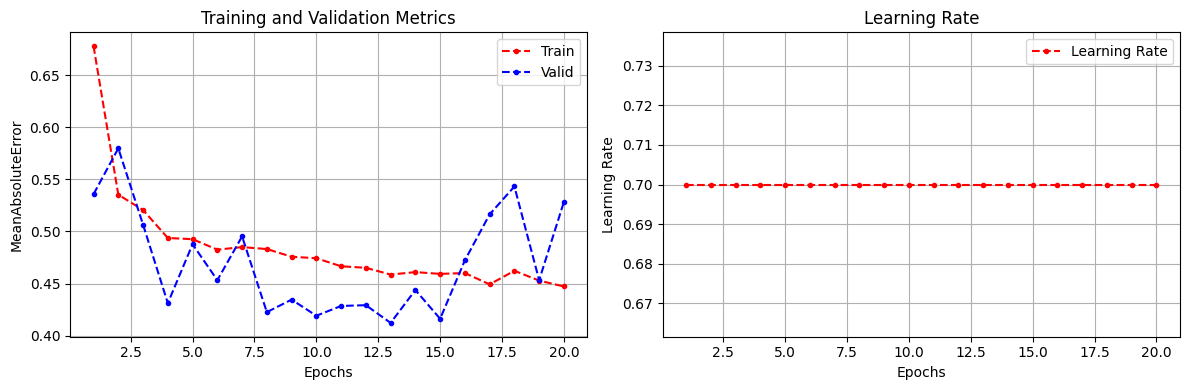

In [40]:
from custom_utils import train, plot_history

n_features = 8
n_hidden1 = 30
n_hidden2 = 50

# model = nn.Sequential(
# 	nn.Linear(
#         in_features=n_features, 
#         out_features=n_hidden1
#     ), 
# 	nn.Sigmoid(),
# 	nn.Linear(
#         in_features=n_hidden1, 
#         out_features=n_hidden2
#     ), 
# 	nn.Sigmoid(),
# 	nn.Linear(
#         in_features=n_hidden2, 
#         out_features=1
#     )
# ).to(device)

class PriceRegressor(nn.Module):
	def __init__(self, n_inputs, n_hidden1, n_hidden2):
		super().__init__()
		# self.n_inputs = n_inputs
		# self.n_hidden1 = n_hidden1
		# self.n_hidden2 = n_hidden2

		self.stack = nn.Sequential(
			nn.Linear(n_inputs, n_hidden1), 
			nn.Sigmoid(), 
			nn.Linear(n_hidden1, n_hidden2), 
			nn.Sigmoid(), 
			nn.Linear(n_hidden2, 1), 
		)

	def forward(self, X):
		y_pred = self.stack(X)
		return y_pred

model = PriceRegressor(8, 30, 50).to(device)

learning_rate = 0.7
n_epochs = 20

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate, momentum=0.2)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(
	model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs=n_epochs, 
	checkpoint_path='best_model.pt',
	clip_grad_norm=3.0
    )
plot_history(history, metric)

In [35]:
class Heyvan:
	def __init__(self, ad):
		self.ad = ad

	def gez(self, km):
		return f'gezdim {km} km'

class It(Heyvan):
	def __init__(self, ad, sort):
		super().__init__(ad)
		self.sort = sort

	def gez(self, m):
		return f'gezdim {m} m'

i1 = It('alibala', 'labrador')
i1.gez(5)

'gezdim 5 m'

torch.Tensor

In [37]:
class PriceRegressor(nn.Module):
	def __init__(self, n_inputs, n_hidden1, n_hidden2):
		super().__init__()
		# self.n_inputs = n_inputs
		# self.n_hidden1 = n_hidden1
		# self.n_hidden2 = n_hidden2

		self.stack = nn.Sequential(
			nn.Linear(n_inputs, n_hidden1), 
			nn.Sigmoid(), 
			nn.Linear(n_hidden1, n_hidden2), 
			nn.Sigmoid(), 
			nn.Linear(n_hidden2, 1), 
		)

	def forward(self, X):
		y_pred = self.stack(X)
		return y_pred

model1 = PriceRegressor(8, 30, 50)
X, y = next(iter(train_loader))
y_pred = model1(X)

Epoch: 1/20, Train Loss: 3.979, Train Metric: 1.138, Valid Metric: 0.841, Time: 2.22s
	Checkpoint, valid metric: 0.841
Epoch: 2/20, Train Loss: 5.601, Train Metric: 1.12, Valid Metric: 1.086, Time: 2.8s
Epoch: 3/20, Train Loss: 4.65, Train Metric: 1.145, Valid Metric: 1.007, Time: 3.06s
Epoch: 4/20, Train Loss: 4.233, Train Metric: 1.144, Valid Metric: 1.319, Time: 2.23s
Epoch: 5/20, Train Loss: 4.887, Train Metric: 1.14, Valid Metric: 0.975, Time: 2.19s
Epoch: 6/20, Train Loss: 3.741, Train Metric: 1.096, Valid Metric: 1.203, Time: 2.28s
Epoch: 7/20, Train Loss: 3.328, Train Metric: 1.099, Valid Metric: 1.343, Time: 2.07s
Epoch: 8/20, Train Loss: 2.86, Train Metric: 1.086, Valid Metric: 0.766, Time: 2.35s
	Checkpoint, valid metric: 0.766
Epoch: 9/20, Train Loss: 3.439, Train Metric: 1.088, Valid Metric: 1.254, Time: 2.46s
Epoch: 10/20, Train Loss: 4.646, Train Metric: 1.117, Valid Metric: 1.45, Time: 2.69s
Epoch: 11/20, Train Loss: 2.45, Train Metric: 1.083, Valid Metric: 1.505, Time:

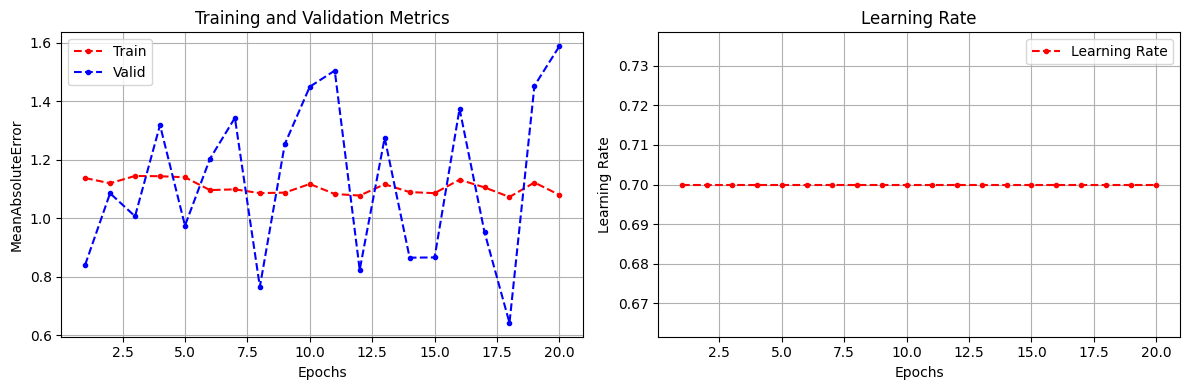

In [50]:
from custom_utils import train, plot_history

n_features = 8
n_hidden1 = 30
n_hidden2 = 50

# model = nn.Sequential(
# 	nn.Linear(
#         in_features=n_features, 
#         out_features=n_hidden1
#     ), 
# 	nn.Sigmoid(),
# 	nn.Linear(
#         in_features=n_hidden1, 
#         out_features=n_hidden2
#     ), 
# 	nn.Sigmoid(),
# 	nn.Linear(
#         in_features=n_hidden2, 
#         out_features=1
#     )
# ).to(device)

class PriceRegressor(nn.Module):
	def __init__(self, n_inputs, n_hidden1, n_hidden2):
		super().__init__()
		self.stack = nn.Sequential(
			nn.Linear(n_inputs, n_hidden1), 
			nn.Sigmoid(), 
			nn.Linear(n_hidden1, n_hidden2), 
			nn.Sigmoid(), 
		)
		self.output = nn.Linear(n_hidden2+n_inputs, 1)

	def forward(self, X):
		output_stack = self.stack(X)
		combined_output = torch.concat([output_stack, X], dim=1)
		y_pred = self.output(combined_output)
		return y_pred

model = PriceRegressor(8, 30, 50).to(device)

learning_rate = 0.7
n_epochs = 20

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate, momentum=0.2)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(
	model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs=n_epochs, 
	checkpoint_path='best_model.pt',
	clip_grad_norm=3.0
    )
plot_history(history, metric)

In [45]:
model.stack(X).shape

torch.Size([32, 50])

In [46]:
X.shape

torch.Size([32, 8])

In [48]:
torch.concat([model.stack(X), X], dim=1).shape

torch.Size([32, 58])

Epoch: 1/20, Train Loss: 1.889, Train Metric: 1.088, Valid Metric: 0.953, Time: 2.92s
	Checkpoint, valid metric: 0.953
Epoch: 2/20, Train Loss: 1.4, Train Metric: 0.944, Valid Metric: 1.156, Time: 3.08s
Epoch: 3/20, Train Loss: 1.482, Train Metric: 0.973, Valid Metric: 1.007, Time: 3.33s
Epoch: 4/20, Train Loss: 1.378, Train Metric: 0.939, Valid Metric: 1.096, Time: 2.38s
Epoch: 5/20, Train Loss: 1.441, Train Metric: 0.974, Valid Metric: 0.453, Time: 2.31s
	Checkpoint, valid metric: 0.453
Epoch: 6/20, Train Loss: 1.522, Train Metric: 1.002, Valid Metric: 0.629, Time: 2.88s
Epoch: 7/20, Train Loss: 1.423, Train Metric: 0.956, Valid Metric: 0.972, Time: 2.83s
Epoch: 8/20, Train Loss: 1.441, Train Metric: 0.972, Valid Metric: 0.864, Time: 2.69s
Epoch: 9/20, Train Loss: 1.437, Train Metric: 0.974, Valid Metric: 1.376, Time: 2.54s
Epoch: 10/20, Train Loss: 1.523, Train Metric: 1.01, Valid Metric: 1.435, Time: 2.34s
Epoch: 11/20, Train Loss: 1.53, Train Metric: 1.015, Valid Metric: 0.878, Ti

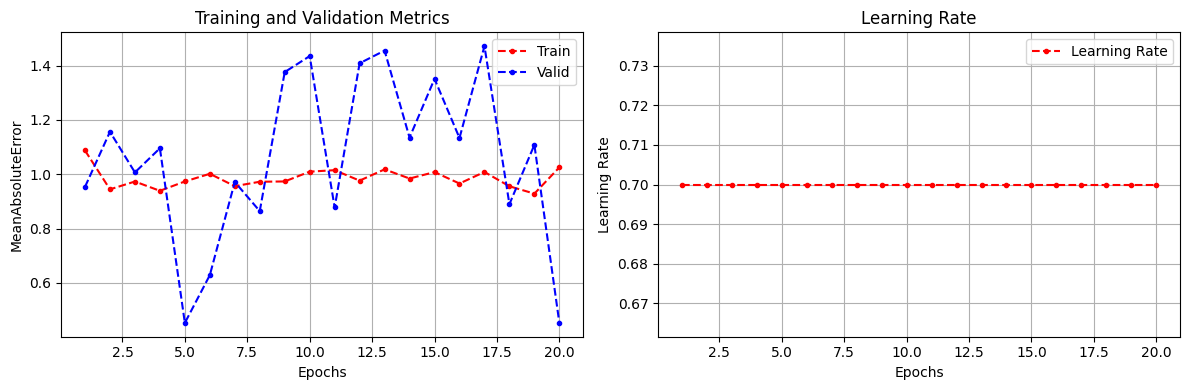

In [51]:
from custom_utils import train, plot_history

n_features = 8
n_hidden1 = 30
n_hidden2 = 50

class PriceRegressor(nn.Module):
	def __init__(self, n_inputs, n_hidden1, n_hidden2):
		super().__init__()
		self.stack = nn.Sequential(
			nn.Linear(n_inputs-2, n_hidden1), 
			nn.Sigmoid(), 
			nn.Linear(n_hidden1, n_hidden2), 
			nn.Sigmoid(), 
		)
		self.output = nn.Linear(n_hidden2+2, 1)

	def forward(self, X):
		X_eco = X[:, :6]
		X_geo = X[:, -2:]
		output_eco = self.stack(X_eco)
		combined_output = torch.concat([output_eco, X_geo], dim=1)
		y_pred = self.output(combined_output)
		return y_pred

model = PriceRegressor(8, 30, 50).to(device)

learning_rate = 0.7
n_epochs = 20

criterion = nn.MSELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=learning_rate, momentum=0.2)
metric = torchmetrics.MeanAbsoluteError().to(device)

history = train(
	model, 
	optimizer, 
	criterion, 
	metric, 
	train_loader, 
	valid_loader, 
	n_epochs=n_epochs, 
	checkpoint_path='best_model.pt',
	clip_grad_norm=3.0
    )
plot_history(history, metric)